# 05 - Ensemble Feature Selection

Eight selectors spanning filter, wrapper, embedded and explainability families -
Variance, one-vs-rest Pearson, Mutual Information, ReliefF, mRMR, RFE, Boruta and
SHAP - are combined by consensus voting.

## The leakage rule this notebook enforces

> **Selectors never see validation or test rows.**

Two levels of protection:

1. The **reported subset** is fitted on the training split only, then applied unchanged
   to val and test.
2. The **CV estimate** re-fits the entire ensemble inside every fold
   (`selector` callback in `grouped_cv`). The submitted version fitted selection once on
   the full training set and then cross-validated on that same set, which inflates the
   CV number even though the test set stayed clean. Section 4 quantifies the gap.

In [1]:
import sys, json, time
from pathlib import Path
EXPERIMENT_DIR = Path(r"/mnt/b6bdcd1c-136a-435b-aeed-0e1b31c32749/Paper_Reeyan/Experiment")
if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIR))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dasfe import config as C, fusion as F, selection as FS, evaluate as EV

sns.set_theme(style="whitegrid", context="notebook")

# ----------------------------- CONFIGURE ME -----------------------------
DATASET    = "tomasov"
SMOKE_TEST = False
TOP_FRAC   = 0.50      # fraction of features each method may keep
# ------------------------------------------------------------------------

suffix   = "_smoke" if SMOKE_TEST else ""
fuse_dir = C.results_dir(DATASET, "04_fusion" + suffix)
sel_dir  = C.results_dir(DATASET, "05_selection" + suffix)

data  = F.load(fuse_dir)
X, y  = data["X"], data["y"]
names = data["feature_names"]
mani  = data["manifest"]
split = mani["split"].to_numpy()
group_key = C.DATASETS[DATASET].group_key
groups = mani[group_key if group_key in mani.columns else "group_id"].to_numpy()

tr = split == "train"
print(f"{DATASET}: X {X.shape}")
print(f"train {tr.sum():,} | val {(split=='val').sum():,} | test {(split=='test').sum():,}")
print(f"split groups: {pd.Series(groups).nunique()}")

tomasov: X (172458, 1002)
train 148,229 | val 12,895 | test 11,334
split groups: 335


## 1. Fit all eight selectors on the training split

`variance` and `pearson` are cheap and run on the full training split. `mutual_info`,
`relieff`, `mrmr`, `rfe`, `boruta` and `shap` use a class-proportional subsample for
tractability - the subsample is drawn from the training split only.

In [2]:
t0 = time.perf_counter()
result = FS.fit_all(X[tr], y[tr], names, top_frac=TOP_FRAC, seed=C.SEED, verbose=True)
print(f"\nensemble selection: {time.perf_counter()-t0:.1f} s "
      f"({result['n_methods']}/8 methods succeeded, each keeping {result['top_k']} features)")

timings = pd.DataFrame([{"method": k, "seconds": round(v, 2)}
                        for k, v in result["timings"].items()]).sort_values("seconds", ascending=False)
display(timings)

  [variance] kept 501/1002 in 0.4s
  [pearson] kept 501/1002 in 4.9s
  [mutual_info] kept 501/1002 in 89.2s
  [relieff] kept 501/1002 in 230.3s
  [mrmr] kept 501/1002 in 174.7s
  [rfe] kept 501/1002 in 259.8s
  [boruta] kept 501/1002 in 665.0s
  [shap] kept 501/1002 in 155.6s

ensemble selection: 1580.1 s (8/8 methods succeeded, each keeping 501 features)


,method,seconds
6,boruta,665.02
5,rfe,259.78
3,relieff,230.31
4,mrmr,174.66
7,shap,155.59
2,mutual_info,89.24
1,pearson,4.94
0,variance,0.38


## 2. Consensus subsets

A feature retained by all eight methods has support across fundamentally different
criteria - linear correlation, information content, neighbourhood separability,
redundancy penalty, tree importance and model attribution.

In [3]:
vote_hist = pd.Series(result["votes"]).value_counts().sort_index(ascending=False)
vote_table = pd.DataFrame({
    "votes": vote_hist.index,
    "n_features": vote_hist.values,
    "cumulative": vote_hist.values.cumsum(),
})
vote_table["reduction_pct"] = (100 * (1 - vote_table.cumulative / X.shape[1])).round(2)
display(vote_table)

for thr in range(result["n_methods"], 0, -1):
    n = int((result["votes"] >= thr).sum())
    print(f"  >= {thr}/8 methods: {n:5d} features  ({100*n/X.shape[1]:5.1f}% kept)")

,votes,n_features,cumulative,reduction_pct
0,8,52,52,94.81
1,7,98,150,85.03
2,6,154,304,69.66
3,5,206,510,49.10
4,4,102,612,38.92
5,3,85,697,30.44
6,2,99,796,20.56
7,1,91,887,11.48
8,0,115,1002,0.00


  >= 8/8 methods:    52 features  (  5.2% kept)
  >= 7/8 methods:   150 features  ( 15.0% kept)
  >= 6/8 methods:   304 features  ( 30.3% kept)
  >= 5/8 methods:   510 features  ( 50.9% kept)
  >= 4/8 methods:   612 features  ( 61.1% kept)
  >= 3/8 methods:   697 features  ( 69.6% kept)
  >= 2/8 methods:   796 features  ( 79.4% kept)
  >= 1/8 methods:   887 features  ( 88.5% kept)


unanimous consensus subset: 52 / 1002 features (94.81% reduction)


,domain,n_selected,n_available,pct_of_selected,retention_pct
0,time,3,112,5.769231,2.678571
1,freq,6,90,11.538462,6.666667
2,tf,35,739,67.307692,4.736130
3,spatial,8,61,15.384615,13.114754


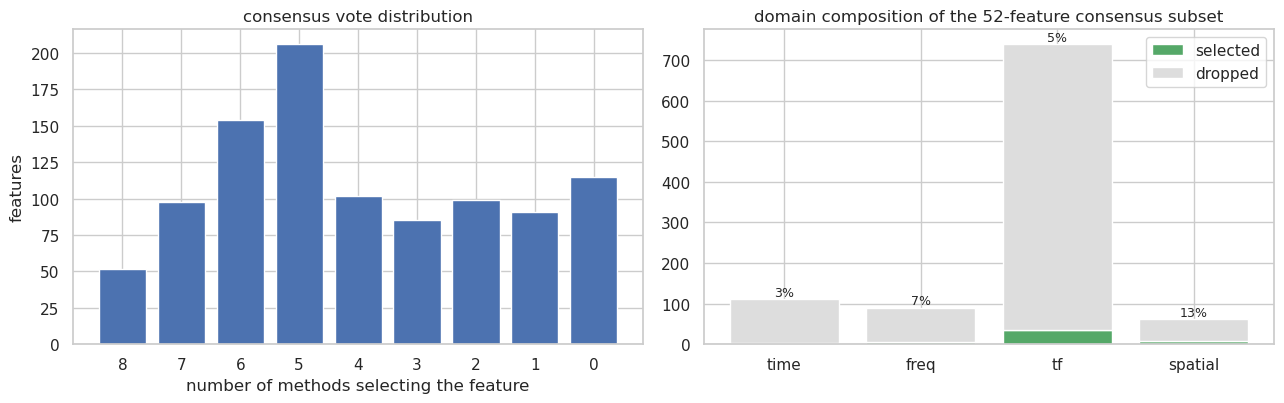

In [4]:
mask_consensus = FS.consensus_mask(result)             # unanimous 8/8
selected = [n for n, m in zip(names, mask_consensus) if m]
print(f"unanimous consensus subset: {mask_consensus.sum()} / {X.shape[1]} features "
      f"({100*(1-mask_consensus.sum()/X.shape[1]):.2f}% reduction)")

comp = F.domain_composition(selected)
display(comp)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].bar(vote_table.votes.astype(str), vote_table.n_features, color="#4C72B0")
axes[0].set_xlabel("number of methods selecting the feature")
axes[0].set_ylabel("features"); axes[0].set_title("consensus vote distribution")

axes[1].bar(comp.domain, comp.n_selected, color="#55A868", label="selected")
axes[1].bar(comp.domain, comp.n_available - comp.n_selected, bottom=comp.n_selected,
            color="#DDDDDD", label="dropped")
axes[1].set_title(f"domain composition of the {mask_consensus.sum()}-feature consensus subset")
axes[1].legend()
for i, r in comp.iterrows():
    axes[1].text(i, r.n_available + 8, f"{r.retention_pct:.0f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(sel_dir / "consensus_votes_and_domains.png", dpi=200)
plt.show()

## 3. Method agreement (Jaccard) and top-ranked features

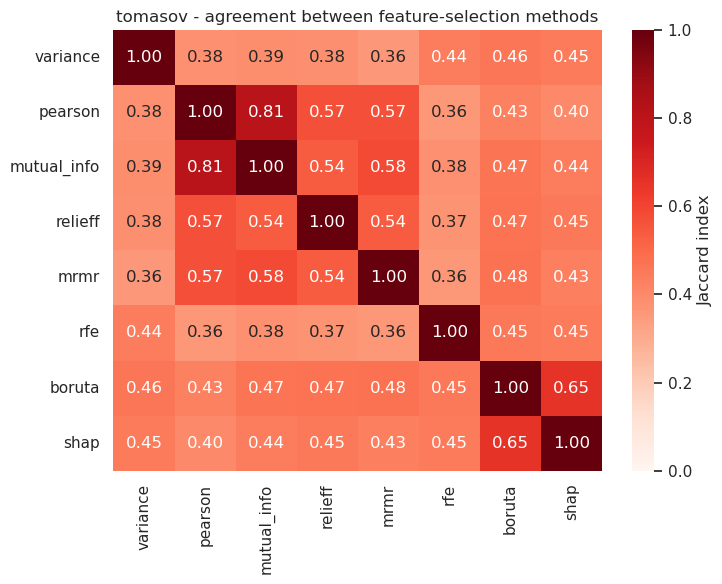

mean pairwise agreement: 0.467
strongest pair : ('pearson', 'mutual_info') = 0.812
weakest pair   : ('variance', 'mrmr') = 0.358


In [5]:
J = FS.jaccard_matrix(result)
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(J, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1, ax=ax,
            cbar_kws={"label": "Jaccard index"})
ax.set_title(f"{DATASET} - agreement between feature-selection methods")
plt.tight_layout()
plt.savefig(sel_dir / "jaccard_agreement.png", dpi=200)
plt.show()

off = J.where(~np.eye(len(J), dtype=bool))
print(f"mean pairwise agreement: {off.stack().mean():.3f}")
print(f"strongest pair : {off.stack().idxmax()} = {off.stack().max():.3f}")
print(f"weakest pair   : {off.stack().idxmin()} = {off.stack().min():.3f}")

,feature,votes,selection_pct,avg_rank,domain
0,SPAT:st_grad_t_energy,8,100.0,37.50,SPAT
1,SPAT:st_grad_c_energy,8,100.0,45.00,SPAT
2,SPAT:st_t_skew,8,100.0,66.00,SPAT
3,SPAT:st_vel_std,8,100.0,80.88,SPAT
4,TF:tfband_2,8,100.0,81.25,TF
5,TF:DWT_L0_tk_mean,8,100.0,81.88,TF
6,SPAT:st_traj_var,8,100.0,119.38,SPAT
7,SPAT:st_traj_range,8,100.0,123.62,SPAT
8,SPAT:st_entropy,8,100.0,127.31,SPAT
9,TF:Ef_kurt,8,100.0,155.62,TF


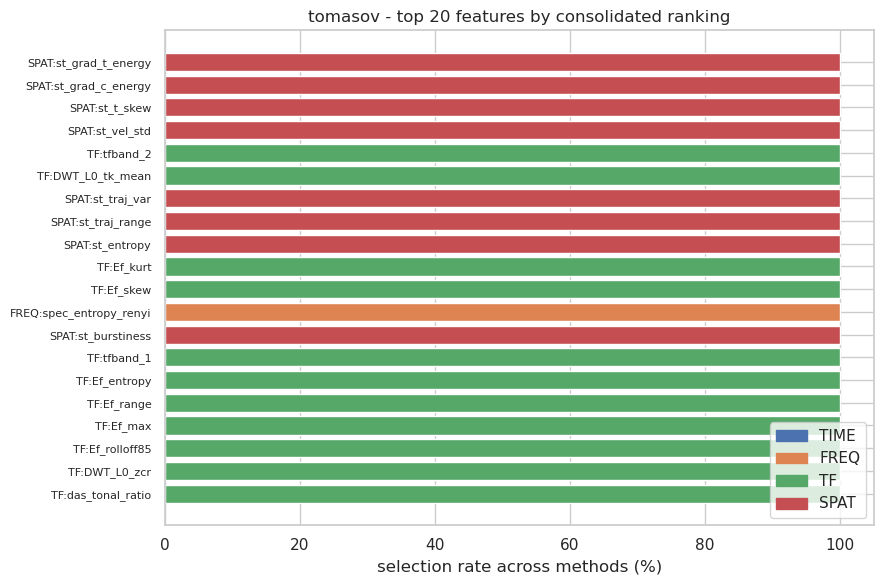

In [6]:
top20 = result["table"].head(20)[["feature", "votes", "selection_pct", "avg_rank"]]
top20 = top20.copy()
top20["domain"] = top20.feature.str.split(":").str[0]
display(top20.round(2))

fig, ax = plt.subplots(figsize=(9, 6))
colors = {"TIME": "#4C72B0", "FREQ": "#DD8452", "TF": "#55A868", "SPAT": "#C44E52"}
ax.barh(range(len(top20)), top20.selection_pct,
        color=[colors.get(d, "grey") for d in top20.domain])
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.feature, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("selection rate across methods (%)")
ax.set_title(f"{DATASET} - top 20 features by consolidated ranking")
handles = [plt.Rectangle((0,0),1,1, color=c) for c in colors.values()]
ax.legend(handles, colors.keys(), loc="lower right")
plt.tight_layout()
plt.savefig(sel_dir / "top20_features.png", dpi=200)
plt.show()

## 4. How much does fitting selection outside the CV loop inflate the estimate?

Both configurations use the identical model and the identical grouped folds. The only
difference is *when* selection happens.

In [7]:
MODEL, STRATEGY = "LightGBM", "class_weight"
BIAS_FOLDS = 3          # the in-fold refit runs the whole ensemble BIAS_FOLDS times
X_tr, y_tr, g_tr = X[tr], y[tr], groups[tr]

# (a) leaky: selection fitted once on the whole training split, then cross-validated
cv_leaky = EV.grouped_cv(X_tr[:, mask_consensus], y_tr, g_tr, MODEL, STRATEGY,
                         n_splits=BIAS_FOLDS, seed=C.SEED)

# (b) honest: the whole 8-method ensemble re-fitted inside every fold.
# `fast=True` shrinks the subsample budgets only - the same 8 methods run.
def fold_selector(Xf, yf):
    r = FS.fit_all(Xf, yf, names, top_frac=TOP_FRAC, seed=C.SEED,
                   verbose=False, fast=True)
    m = FS.consensus_mask(r)
    return m if m.sum() >= 10 else (r["votes"] >= max(1, r["n_methods"] - 1))

t0 = time.perf_counter()
cv_honest = EV.grouped_cv(X_tr, y_tr, g_tr, MODEL, STRATEGY,
                          n_splits=BIAS_FOLDS, seed=C.SEED, selector=fold_selector)
print(f"in-fold ensemble refit x{BIAS_FOLDS}: {time.perf_counter()-t0:.0f}s")

m_l, lo_l, hi_l = EV.ci95(cv_leaky.f1_macro)
m_h, lo_h, hi_h = EV.ci95(cv_honest.f1_macro)
bias = pd.DataFrame([
    {"protocol": "selection fitted once on full train (submitted)",
     "cv_f1_macro": round(100*m_l, 2), "ci95_low": round(100*lo_l, 2), "ci95_high": round(100*hi_l, 2)},
    {"protocol": "selection re-fitted inside each fold (revised)",
     "cv_f1_macro": round(100*m_h, 2), "ci95_low": round(100*lo_h, 2), "ci95_high": round(100*hi_h, 2)},
])
bias.loc[len(bias)] = ["optimism (pp)", round(100*(m_l - m_h), 2), "", ""]
display(bias)
bias.to_csv(sel_dir / "selection_bias_analysis.csv", index=False)

in-fold ensemble refit x3: 918s


,protocol,cv_f1_macro,ci95_low,ci95_high
0,selection fitted once on full train (submitted),71.40,65.67,77.13
1,selection re-fitted inside each fold (revised),71.39,65.49,77.28
2,optimism (pp),0.02,,


## 5. Dimensionality-performance trade-off

How far can the feature space be cut before accuracy falls off? Subsets are taken from
the consolidated consensus ranking (training data only) and evaluated on validation.

In [8]:
order = np.argsort(-result["table"].set_index("feature").loc[names, "votes"].to_numpy()
                   + result["table"].set_index("feature").loc[names, "avg_rank"].to_numpy() / 1e6)
K_GRID = [k for k in (10, 20, 40, 80, 120, 160, 200, 271, 400, 600, 800, X.shape[1])
          if k <= X.shape[1]]

curve = []
va = split == "val"
for k in K_GRID:
    cols = order[:k]
    r = EV.fit_predict(MODEL, STRATEGY, X[tr][:, cols], y[tr], X[va][:, cols], y[va], C.SEED)
    curve.append({"k": k, **{m: r["metrics"][m] for m in
                             ("accuracy", "balanced_accuracy", "f1_macro")},
                  "train_seconds": r["metrics"]["train_seconds"]})
curve = pd.DataFrame(curve)
display(curve.round(4))

,k,accuracy,balanced_accuracy,f1_macro,train_seconds
0,10,0.6665,0.6525,0.6442,18.4381
1,20,0.7049,0.7103,0.7069,24.3795
2,40,0.7190,0.7281,0.7255,40.4763
3,80,0.7458,0.7471,0.7476,44.8588
4,120,0.7486,0.7466,0.7489,61.9335
5,160,0.7505,0.7519,0.7533,79.3921
6,200,0.8244,0.8066,0.8070,103.6517
7,271,0.8238,0.8053,0.8064,140.8541
8,400,0.8800,0.8514,0.8504,225.2194
9,600,0.8969,0.8661,0.8653,354.3389


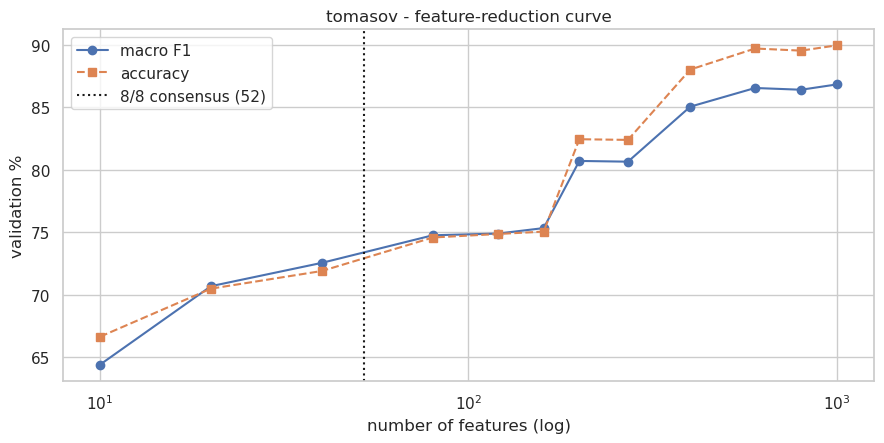

best   : k=1002  F1=86.82%
full   : k=1002  F1=86.82%
consensus subset keeps 5.2% of the features


In [9]:
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(curve.k, 100*curve.f1_macro, "o-", label="macro F1", color="#4C72B0")
ax.plot(curve.k, 100*curve.accuracy, "s--", label="accuracy", color="#DD8452")
ax.axvline(int(mask_consensus.sum()), color="k", ls=":",
           label=f"8/8 consensus ({int(mask_consensus.sum())})")
ax.set_xscale("log"); ax.set_xlabel("number of features (log)"); ax.set_ylabel("validation %")
ax.set_title(f"{DATASET} - feature-reduction curve")
ax.legend(); plt.tight_layout()
plt.savefig(sel_dir / "feature_reduction_curve.png", dpi=200)
plt.show()

best = curve.loc[curve.f1_macro.idxmax()]
full = curve.loc[curve.k.idxmax()]
print(f"best   : k={int(best.k):4d}  F1={100*best.f1_macro:.2f}%")
print(f"full   : k={int(full.k):4d}  F1={100*full.f1_macro:.2f}%")
print(f"consensus subset keeps {100*mask_consensus.sum()/X.shape[1]:.1f}% of the features")

## 6. Save the selection artefacts

`fs_masks_multi.npz` holds one boolean mask per method; downstream notebooks load it and
never re-run selection, so the reported subsets are frozen.

In [10]:
FS.save(result, sel_dir, tag="multi")
np.save(sel_dir / "mask_consensus.npy", mask_consensus)
np.save(sel_dir / "rank_order.npy", order)
curve.to_csv(sel_dir / "reduction_curve.csv", index=False)
comp.to_csv(sel_dir / "domain_composition.csv", index=False)
timings.to_csv(sel_dir / "method_timings.csv", index=False)
json.dump({"selected_features": selected}, open(sel_dir / "consensus_features.json", "w"), indent=1)

print("wrote", sel_dir)
for p in sorted(sel_dir.iterdir()):
    print("  ", p.name)

wrote /mnt/b6bdcd1c-136a-435b-aeed-0e1b31c32749/Paper_Reeyan/Results/tomasov/05_selection
   consensus_features.json
   consensus_votes_and_domains.png
   domain_composition.csv
   feature_reduction_curve.png
   fs_jaccard_multi.csv
   fs_masks_multi.npz
   fs_table_multi.csv
   fs_timings_multi.json
   fs_votes_multi.npy
   jaccard_agreement.png
   mask_consensus.npy
   method_timings.csv
   rank_order.npy
   reduction_curve.csv
   selection_bias_analysis.csv
   top20_features.png


---
**Next:** `06_balancing_and_model_benchmark.ipynb` - seven classifiers x six balancing
strategies, with every resampler confined inside the training fold.